# Terrain → Spring Phenology Mediation
Tests the causal chain: terrain constrains soil moisture → drives spring greenup rate → locks in harvest-season canopy structure.

Step 1: Confirm spring greenup rate (ndvi_smooth_slope_21) predicts harvest anomaly (already shown by SHAP).
Step 2: OLS — terrain features → ndvi_smooth_slope_21 (per plot, averaged across years).
If terrain explains greenup rate, the chain closes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os

os.makedirs('../img', exist_ok=True)

In [2]:
df = pd.read_pickle('../data/df.pkl')

# Per-plot means (collapse year dimension; greenup rate is a plot-level tendency)
plot_df = df.groupby('plot_id').agg(
    slope_21=('ndvi_smooth_slope_21', 'mean'),
    slope_22=('ndvi_smooth_slope_22', 'mean'),
    slope_25=('ndvi_smooth_slope_25', 'mean'),
    # Terrain (static per plot — same in every row)
    elev_mean=('elev_mean', 'first'),
    elev_min=('elev_min', 'first'),
    elev_max=('elev_max', 'first'),
    slope_x=('slope_x', 'first'),
    slope_y=('slope_y', 'first'),
    aspect_sin=('aspect_mean_sin', 'first'),
    aspect_cos=('aspect_mean_cos', 'first'),
    pro_curve=('pro_curve_mean', 'first'),
    plan_curve=('plan_curve_mean', 'first'),
    # Soil
    awc=('awc_r', 'first'),
    ph=('ph1to1h2o_r', 'first'),
    clay=('claytotal_r', 'first'),
    restric=('restrictiondepth_cm', 'first'),
    # Mean harvest anomaly (to check step 1)
    mean_anomaly_36=('ndvi_anomaly_36', 'mean'),
    mean_anomaly_40=('ndvi_anomaly_40', 'mean'),
).reset_index()

plot_df = plot_df.dropna()
print(f'Plots with complete data: {len(plot_df)}')

Plots with complete data: 2046


In [3]:
# --- Step 1: Confirm greenup rate predicts harvest anomaly ---
X1 = sm.add_constant(plot_df['slope_21'])
for target in ['mean_anomaly_36', 'mean_anomaly_40']:
    res = sm.OLS(plot_df[target], X1).fit()
    print(f'slope_21 → {target}: R²={res.rsquared:.3f}, β={res.params["slope_21"]:.4f}, p={res.pvalues["slope_21"]:.2e}')

slope_21 → mean_anomaly_36: R²=0.254, β=34.5315, p=2.51e-132
slope_21 → mean_anomaly_40: R²=0.218, β=27.4428, p=1.93e-111


In [4]:
# --- Step 2: OLS — terrain+soil → ndvi_smooth_slope_21 ---
terrain_soil_cols = ['elev_mean', 'slope_x', 'aspect_sin', 'aspect_cos',
                     'pro_curve', 'plan_curve', 'awc', 'ph', 'clay', 'restric']

X2 = plot_df[terrain_soil_cols].copy()
# Standardize for coefficient comparability
X2_std = (X2 - X2.mean()) / X2.std()
X2_std = sm.add_constant(X2_std)
y2 = plot_df['slope_21']

model2 = sm.OLS(y2, X2_std).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:               slope_21   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.159
Method:                 Least Squares   F-statistic:                     44.12
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           8.98e-73
Time:                        06:03:24   Log-Likelihood:                 10835.
No. Observations:                2046   AIC:                        -2.165e+04
Df Residuals:                    2036   BIC:                        -2.159e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0024   2.69e-05     88.845      0.0

In [5]:
# --- VIF check ---
vif_data = pd.DataFrame()
vif_data['feature'] = terrain_soil_cols
X2_noconst = X2_std.drop(columns='const')
vif_data['VIF'] = [variance_inflation_factor(X2_noconst.values, i) for i in range(X2_noconst.shape[1])]
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))

   feature      VIF
      clay      inf
        ph      inf
       awc      inf
   slope_x 8.929355
aspect_cos 8.278226
   restric 3.670862
aspect_sin 1.235272
 elev_mean 1.209249
 pro_curve 1.023333
plan_curve 1.016824


/home/simonhans/anaconda3/envs/GrapeExpectationsML/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


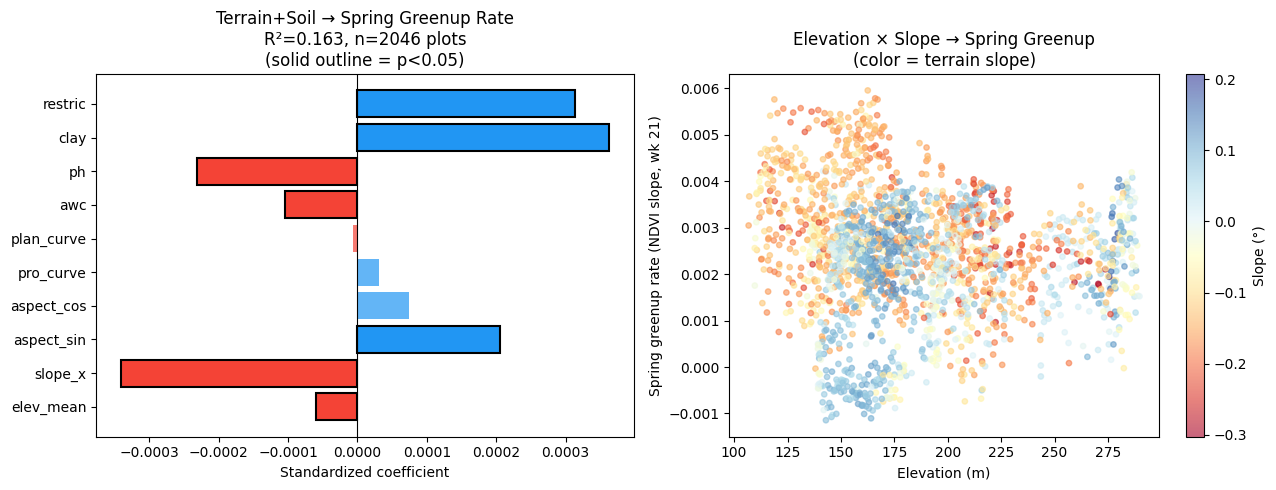

In [6]:
# --- Coefficient bar chart (significant predictors only) ---
params = model2.params.drop('const')
pvals = model2.pvalues.drop('const')
sig = pvals < 0.05

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: coefficient bar chart
ax = axes[0]
colors = ['#2196F3' if v > 0 else '#F44336' for v in params.values]
bars = ax.barh(params.index, params.values, color=colors, alpha=0.7)
# Mark significant ones with bold outline
for i, (p, s) in enumerate(zip(params.values, sig.values)):
    if s:
        ax.barh(params.index[i], p, color=colors[i], alpha=1.0, edgecolor='black', linewidth=1.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized coefficient')
ax.set_title(f'Terrain+Soil → Spring Greenup Rate\nR²={model2.rsquared:.3f}, n={len(plot_df)} plots\n(solid outline = p<0.05)')

# Right: scatter — elev_mean vs slope_21 (top predictor typically)
ax2 = axes[1]
sc = ax2.scatter(plot_df['elev_mean'], plot_df['slope_21'],
                 c=plot_df['slope_x'], cmap='RdYlBu', alpha=0.6, s=15)
plt.colorbar(sc, ax=ax2, label='Slope (°)')
ax2.set_xlabel('Elevation (m)')
ax2.set_ylabel('Spring greenup rate (NDVI slope, wk 21)')
ax2.set_title('Elevation × Slope → Spring Greenup\n(color = terrain slope)')

plt.tight_layout()
plt.savefig('../img/mediation_terrain_greenup.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# --- Path diagram summary ---
print('=== Mediation path summary ===')
print(f'Path A: terrain+soil → greenup rate (slope_21)    R² = {model2.rsquared:.3f}')

X1b = sm.add_constant(plot_df['slope_21'])
res1b = sm.OLS(plot_df['mean_anomaly_36'], X1b).fit()
print(f'Path B: greenup rate → harvest anomaly (wk 36)    R² = {res1b.rsquared:.3f}')
print()
print('Significant terrain predictors of greenup rate:')
for feat, coef, pval in zip(params.index, params.values, pvals.values):
    if pval < 0.05:
        direction = '+' if coef > 0 else '-'
        print(f'  {direction} {feat}: β={coef:.3f}, p={pval:.3e}')

=== Mediation path summary ===
Path A: terrain+soil → greenup rate (slope_21)    R² = 0.163
Path B: greenup rate → harvest anomaly (wk 36)    R² = 0.254

Significant terrain predictors of greenup rate:
  - elev_mean: β=-0.000, p=4.504e-02
  - slope_x: β=-0.000, p=2.278e-05
  + aspect_sin: β=0.000, p=9.311e-12
  - awc: β=-0.000, p=2.696e-05
  - ph: β=-0.000, p=5.446e-10
  + clay: β=0.000, p=2.653e-18
  + restric: β=0.000, p=1.312e-09
